<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/Week%202-3/1-Scrapping-BluAppReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Scrapping Blu App Review**
**Google Play Blu: https://play.google.com/store/apps/details?id=com.bcadigital.blu**


# **Setup and Import Libraries**

In [1]:
!pip install google-play-scraper
!pip install textblob
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 9.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 11.8 MB/s  0:00:00

   ---------------------------------------- 0/3 [regex]
   ------------- -------------------------- 1/3 [nltk]
   ------------- -------------------------- 1/3 [nltk]
   ------------- -------------------------- 1/3 [nltk]
   ------------- -------------------------- 1/3 [nltk]
   ------------- -------------------------- 1/3 [nltk]
   ------------- -------------------------- 1/3 [nltk]
   ------------- -------------------------- 1/3 [nltk]
   ------------- -------------------------- 1/3 [nltk]
   ------------- -------------------------- 1/3 [nltk]
 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import os

#**Data Scrapping**
Android App blu by BCA link from Google Play at https://play.google.com/store/apps/details?id=com.bcadigital.blu. The apps ID found in the link after id=com.bcadigital.blu. The apps name on Google Play titled: blu by BCA Digital. Dated 2 March 2026 | Number of reviews: 113k




In [3]:
from google_play_scraper import app, Sort, reviews_all

blu_reviews = reviews_all(
    'com.bcadigital.blu',
    sleep_milliseconds=0,
    lang='id',
    sort=Sort.NEWEST,
)

In [4]:
os.makedirs('../data', exist_ok=True)

# Save the blu Apps reviews into dataframe
df_bluRev = pd.DataFrame(np.array(blu_reviews), columns=['content'])
df_bluRev = df_bluRev.join(pd.DataFrame(df_bluRev.pop('content').tolist()))

df_bluRev.to_csv(r'../data/bluapp_reviews.csv', index=False)
df_bluRev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,11a53b42-c2cd-4506-bc03-81f53ef395e3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"verifikasi wajah tidak jelas,stuck di pastikan...",1,0,NaN,2026-05-16 23:08:41,"Hai, Kak Darma. Maaf atas ketidaknyamanannya. ...",2026-05-17 00:07:20,NaN
1,50f6878c-3db8-447e-9603-e1676aa60114,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hihihihi kog ngeri nian baca review penggunany...,1,0,NaN,2026-05-16 22:10:32,"Hai, Kak Maulana. Maaf atas ketidaknyamanannya...",2026-05-16 23:06:54,NaN
2,dfb3aa7a-273e-40f8-8c1d-e839818b53ce,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gak perlu di instal hanya menghabiskan paket d...,1,0,2.12.10,2026-05-16 21:52:46,"Hai, Kak Jaki. Maaf atas ketidaknyamanannya. K...",2026-05-16 21:55:55,2.12.10
3,6635a38a-b66c-4012-9bbf-7b08d99862bd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,wish keren sih..ini bank digital yang aku suka..,5,0,2.12.10,2026-05-16 21:11:37,"Hai, Kak Alan. Terima kasih atas ulasannya. Se...",2026-05-16 21:54:10,2.12.10
4,3fa58886-c2f2-456a-8007-bc7888445931,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi kocak, verifikasi wajah gak bisa bisa...",1,0,NaN,2026-05-16 20:47:26,"Hai, Kak Muhammad. Maaf atas ketidaknyamananny...",2026-05-16 21:53:27,NaN


In [5]:
print(df_bluRev.reviewCreatedVersion.unique())

<ArrowStringArray>
[      nan, '2.12.10',  '2.12.0',  '2.11.0', '2.10.20',   '2.6.0',  '2.10.0',
  '1.65.0',   '2.3.0',  '2.7.10',
 ...
  '1.16.0', '1.24.10',  '1.11.0',   '1.8.0',   '1.5.0',   '1.3.2',   '1.4.0',
   '1.2.1',   '1.3.3',   '1.3.0']
Length: 113, dtype: str


**Drop Unnecessary Column Selection**

*   List item
*   List item



In [6]:
# Drop reviewId, userName, userImage
df_bluRev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"verifikasi wajah tidak jelas,stuck di pastikan...",1,0,NaN,2026-05-16 23:08:41,"Hai, Kak Darma. Maaf atas ketidaknyamanannya. ...",2026-05-17 00:07:20
1,hihihihi kog ngeri nian baca review penggunany...,1,0,NaN,2026-05-16 22:10:32,"Hai, Kak Maulana. Maaf atas ketidaknyamanannya...",2026-05-16 23:06:54
2,gak perlu di instal hanya menghabiskan paket d...,1,0,2.12.10,2026-05-16 21:52:46,"Hai, Kak Jaki. Maaf atas ketidaknyamanannya. K...",2026-05-16 21:55:55
3,wish keren sih..ini bank digital yang aku suka..,5,0,2.12.10,2026-05-16 21:11:37,"Hai, Kak Alan. Terima kasih atas ulasannya. Se...",2026-05-16 21:54:10
4,"aplikasi kocak, verifikasi wajah gak bisa bisa...",1,0,NaN,2026-05-16 20:47:26,"Hai, Kak Muhammad. Maaf atas ketidaknyamananny...",2026-05-16 21:53:27
...,...,...,...,...,...,...,...
26525,"Selamat pagi masyarakat BCA DIGITAL, hehehehe😁...",5,0,1.3.2,2021-07-02 09:59:18,"Hai, Kak Ridwan Mukti Sastama. Terima kasih at...",2021-07-04 15:24:53
26526,"Ribet ...minta diaktifkan screen lock, dah akt...",1,0,1.3.2,2021-07-02 09:53:23,"Hai, Kak Hidayat Hidayat. Terima kasih untuk f...",2021-07-04 14:59:53
26527,Video call kok ngk berhasil,5,0,1.3.2,2021-07-02 09:50:42,"Hai, Kak Roni Susanto. Terima kasih untuk feed...",2021-07-04 14:49:57
26528,Pertamax....test,3,1,NaN,2021-07-02 09:42:19,"Hai, Kak Zainal CorRosion. Terima kasih atas u...",2021-07-04 14:34:47


### **Exploratory Data Analysis**

**Score Distribution Analysis**

In [7]:
# Check number of reviews scores
df_bluRev['score'].value_counts()

score
5    15086
1     6140
4     1997
3     1804
2     1503
Name: count, dtype: int64

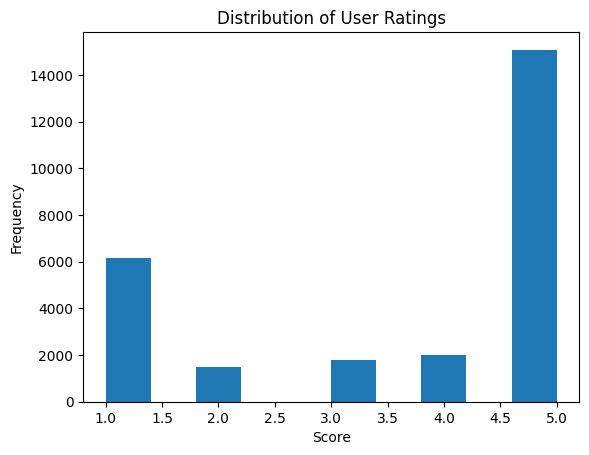

In [8]:
# Visualization
plt.hist(df_bluRev['score'])
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of User Ratings')
plt.show()

**Version-wise Rating Analysis**

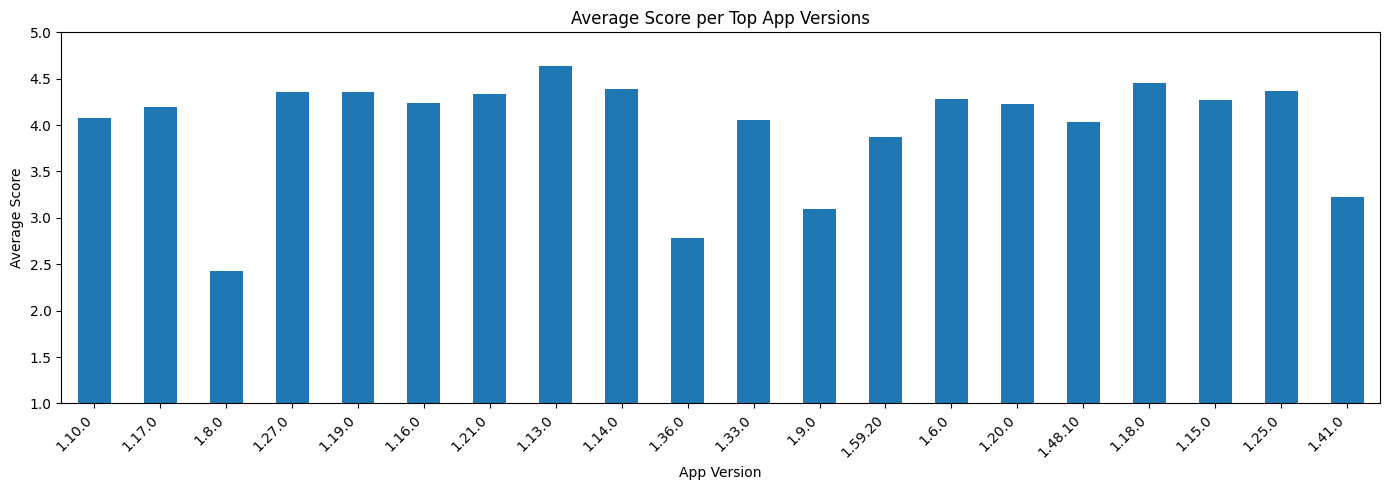

In [9]:
# Top 20 app versions by number of reviews
top_versions = df_bluRev['reviewCreatedVersion'].value_counts().head(20).index

# Calculate average score per version
avg_score_per_version = (
    df_bluRev[df_bluRev['reviewCreatedVersion'].isin(top_versions)]
    .groupby('reviewCreatedVersion')['score']
    .mean()
    .loc[top_versions]
)

# Visualization
plt.figure(figsize=(14,5))
avg_score_per_version.plot(kind='bar')

plt.xlabel('App Version')
plt.ylabel('Average Score')
plt.title('Average Score per Top App Versions')
plt.xticks(rotation=45, ha='right')
plt.ylim(1,5)

plt.tight_layout()
plt.show()

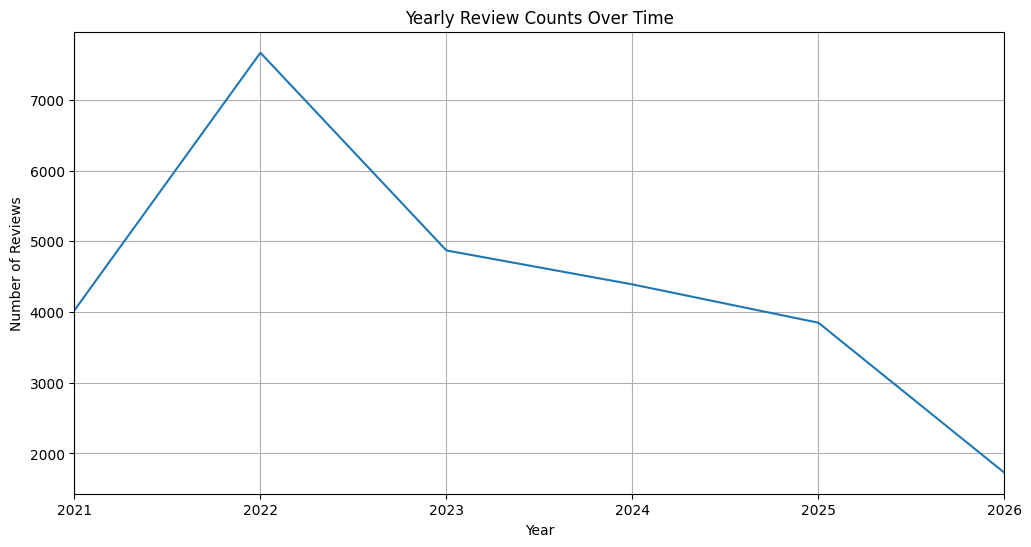

In [10]:
# Extract review date
df_bluRev['at'] = pd.to_datetime(df_bluRev['at'], errors='coerce')
df_bluRev['review_year'] = df_bluRev['at'].dt.to_period('Y')
review_trend = df_bluRev.groupby('review_year').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Yearly Review Counts Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()